# quanTIseq immune deconvolution

**quanTIseq 免疫细胞反卷积**

Use the TIL10 reference with explicit tumor RNA-seq settings and RNA-content correction.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
tpm = tpm_input()
input_shape = tpm.shape
display(tpm.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
MT-CO1,25097.553024,24055.972843,59199.134752,50164.981725
MT-ND4,14525.308129,14963.923341,48195.670862,32185.130734
MT-CO3,12465.198276,14835.808744,47590.766557,34559.374807
IGKC,9897.134453,78664.047321,713.537221,4372.862276
MT-CO2,12920.617435,13063.071078,33664.670548,21527.455301


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.quantiseq(tpm, arrays=False, tumor=True, mRNAscale=True, method="lsei", rmgenes="default")
elapsed = perf_counter() - started
display(save_result(result, "09_quantiseq", elapsed, input_shape))

Running quanTIseq deconvolution module
Gene expression normalization and re-annotation (arrays: False)
Removing 17 noisy genes
Removing 15 genes with high expression in tumors
Signature genes found in data set: 137/138 (99.28%)
Mixture deconvolution (method: lsei)


Deconvoluting samples:   0%|          | 0/10 [00:00<?, ?it/s]

Deconvoluting samples: 100%|██████████| 10/10 [00:00<00:00, 8211.25it/s]

Deconvoluting samples:   0%|          | 0/10 [00:00<?, ?it/s]

Deconvoluting samples: 100%|██████████| 10/10 [00:00<00:00, 9733.82it/s]

Deconvolution successful!
Completed in 0.534 s; input 48,058 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,09_quantiseq,0.534024,"[48058, 10]","{'result': [10, 12]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,Sample,B.cells,Macrophages.M1,Macrophages.M2,Monocytes,Neutrophils,NK.cells,T.cells.CD4,T.cells.CD8,Tregs,Dendritic.cells,Other
0,TCGA-BR-6455,0.007694,0.041177,0.045193,0.000000,0.085319,0.011809,0.000000,0.033796,0.039910,0.0,0.735103
1,TCGA-BR-7196,0.023564,0.081841,0.085686,0.000000,0.017416,0.013969,0.000000,0.024923,0.062433,0.0,0.690167
2,TCGA-BR-8371,0.067845,0.000000,0.046809,0.015634,0.007072,0.005706,0.052311,0.001355,0.010088,0.0,0.793179
3,TCGA-BR-8380,0.013611,0.022082,0.063916,0.006536,0.028324,0.017870,0.004568,0.002197,0.025140,0.0,0.815757
4,TCGA-BR-8592,0.027813,0.008198,0.068206,0.003712,0.027097,0.011836,0.035953,0.006017,0.025558,0.0,0.785610


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

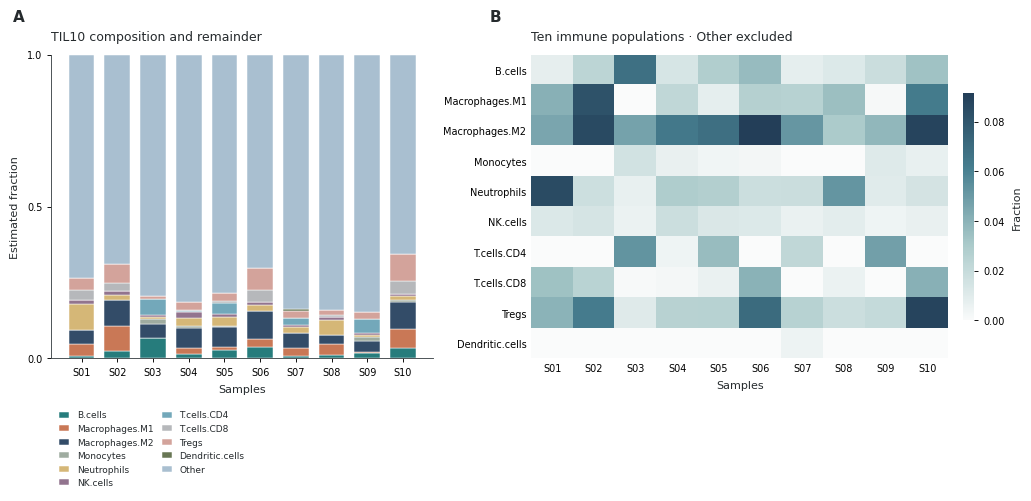

In [5]:
cells = fractions(result, id_column="Sample")
fig, axes, legends = composition_figure(figsize=(10.2, 4.9), ratios=(1.1, 1.2))
stacked(axes[0], cells, max_types=12, legend_ax=legends[0])
immune_cells = cells.drop(columns=[c for c in cells if c.lower() == "other"])
heatmap(axes[1], immune_cells.T, max_rows=12, max_samples=10, scale=False)
panel(axes[0], "A", "TIL10 composition and remainder")
panel(axes[1], "B", "Ten immune populations · Other excluded")
save_figure(fig, '09_quantiseq')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

Use linear-scale expression and compatible human symbols. The uncharacterized 'Other' fraction is a model remainder, not a confirmed cell identity. Cell fractions from different deconvolution methods use different reference sets and must not be compared as interchangeable ground truth.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/09_quantiseq.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.